# Credit Card Fraud Detection System

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Loading the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Data Preprocessing & Preparing Datasets

In [4]:
# checking the missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Observes statistical info of the dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
# Dropping the 'Time' attribute - it does not impact the target variable and is of no use to build the models.
df.drop('Time', axis=1, inplace=True)

In [8]:
X = df.drop('Class', axis=1)
y = df['Class']
X.shape, y.shape

((284807, 29), (284807,))

# Normalizing Amount attribute values using StandardScaler

In [9]:
temp_df = df.copy()

In [10]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()
amount = temp_df['Amount'].values
temp_df['Amount'] = standard.fit_transform(amount.reshape(-1,1))
X_scaled = temp_df.drop('Class', axis=1)
y_scaled = temp_df['Class']
X_scaled.shape, y_scaled.shape

((284807, 29), (284807,))

In [11]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Exploratory Data Analysis(EDA) & Visualization

In [12]:
class_count_df = pd.DataFrame(df['Class'].value_counts().rename_axis('Class').reset_index(name='Counts'))
class_count_df['Class'].replace({0:'Normal',
                                 1:'Fraud'}, inplace=True)
class_count_df.head()

/tmp/ipykernel_2643/1637857004.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  class_count_df['Class'].replace({0:'Normal',


,Class,Counts
0,Normal,284315
1,Fraud,492


/tmp/ipykernel_2643/1475047372.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=list(class_count_df['Class']) ,c='blue', rotation=0, fontsize=10, fontweight='bold')
/tmp/ipykernel_2643/1475047372.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=labels.astype(int), c='blue', fontsize=8, fontweight='bold')


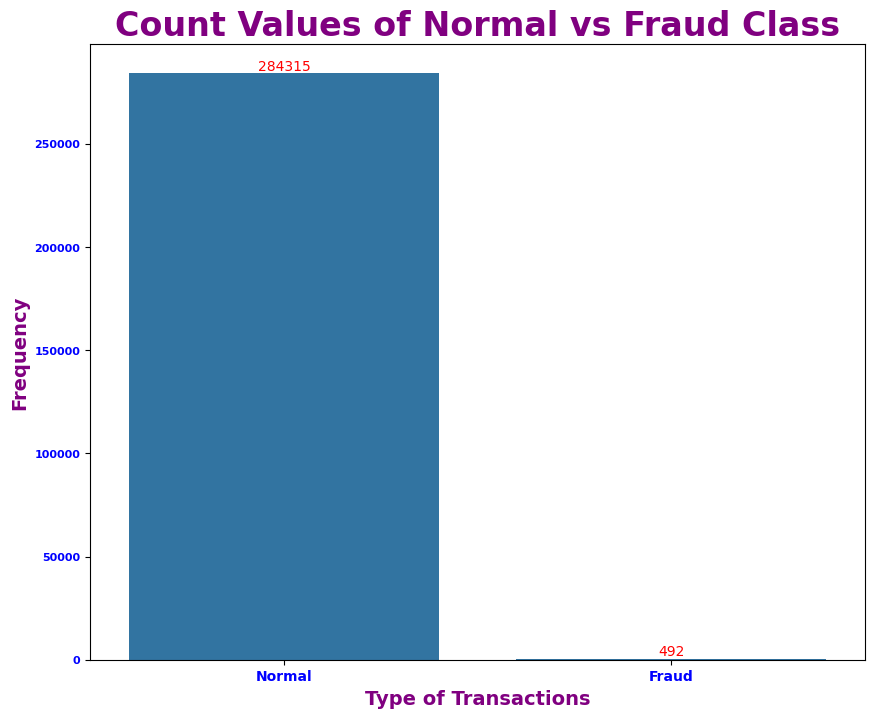

In [13]:
fig = plt.figure()
fig.set_figheight(8)
fig.set_figwidth(10)

ax = sns.barplot(x=class_count_df['Class'],
                 y=class_count_df['Counts'])

ax.bar_label(ax.containers[0], color='red') ## Showing Values at top of Each Bar.

ax.set_xticklabels(labels=list(class_count_df['Class']) ,c='blue', rotation=0, fontsize=10, fontweight='bold')
labels, location = plt.yticks()
ax.set_yticklabels(labels=labels.astype(int), c='blue', fontsize=8, fontweight='bold')

plt.xlabel(xlabel='Type of Transactions', fontsize=14, fontweight='bold').set_color('purple')
plt.ylabel(ylabel='Frequency', fontsize=14, fontweight='bold').set_color('purple')
plt.title(label='Count Values of Normal vs Fraud Class', fontsize=24, fontweight='bold').set_color('purple')

In [14]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]
fraud.shape, normal.shape

((492, 30), (284315, 30))

In [15]:
fraud_frc = len(fraud)/float(len(df))
fraud_frc

0.001727485630620034

In [16]:
print(f"Percentage of Fraud Tnx in datasets : {fraud_frc*100:.2f}%")

Percentage of Fraud Tnx in datasets : 0.17%


In [17]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [18]:
normal.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


# Histogram

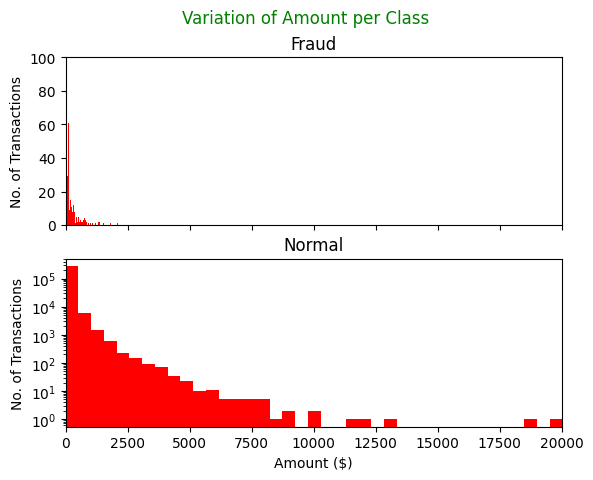

In [19]:
fig, (ax0, ax1) = plt.subplots(nrows=2,
                               ncols=1,
                               sharex=True)
fig.suptitle("Variation of Amount per Class", color='green')
bins=50
ax0.hist(fraud['Amount'], bins=bins, color='red')
ax0.set_title('Fraud')
ax0.set_ylim(0, 100)
ax0.set_ylabel('No. of Transactions')

ax1.hist(normal['Amount'], bins=bins, color='red')
ax1.set_title('Normal')
ax1.set_ylabel('No. of Transactions')

plt.xlim(0, 20000)
plt.xlabel('Amount ($)')
plt.yscale('log')

# Handling Imbalanced datasets

For an imbalanced class dataset, F1 score is a more appropriate metric. F1 score is defined as the harmonic mean between precision and recall. It is used as a statistical measure to rate performance. F1-score ranges between 0 and 1. The closer it is to 1, the better the model.

**OverSampling**

In [20]:
df.Class.value_counts()

,count
Class,
0,284315
1,492


In [21]:
from sklearn.utils import resample
#create two different dataframe of majority and minority class
df_majority = df[(df['Class']==0)]
df_minority = df[(df['Class']==1)]

# upsample minority class
df_minority_oversampled = resample(df_minority,
                                 replace=True,
                                 n_samples=284315,
                                 random_state=42)
# Combine majority class with upsampled minority class
df_oversampled = pd.concat([df_minority_oversampled, df_majority])
df_oversampled.Class.value_counts()

,count
Class,
1,284315
0,284315


In [22]:
X_oversampled = df_oversampled.drop('Class', axis=1)
y_oversampled = df_oversampled['Class']
X_oversampled.shape, y_oversampled.shape

((568630, 29), (568630,))

**UnderSampling**

In [23]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Drop rows with NaN values from X and y
X_cleaned = X.dropna()
y_cleaned = y.dropna()

rus = RandomUnderSampler(random_state=42)

X_undersampled, y_undersampled = rus.fit_resample(X_cleaned, y_cleaned)
print(f"The number of Classes before the fit {Counter(y_cleaned)}")
print(f"The number of Classes after the fit {Counter(y_undersampled)}")

The number of Classes before the fit Counter({0: 284315, 1: 492})
The number of Classes after the fit Counter({0: 492, 1: 492})


# SMOTE(Synthetic Minority Oversampling Technique)

In [24]:
from imblearn.over_sampling import SMOTE

# Resampling the minority class. The strategy can be changed as required.

sm = SMOTE(sampling_strategy='minority', random_state=42)

# Fit the model to generate the data.

# Ensure X and y are cleaned of NaN values before applying SMOTE
X_smote, y_smote = sm.fit_resample(X_cleaned, y_cleaned)
smote_df = pd.concat([pd.DataFrame(X_smote), pd.DataFrame(y_smote)], axis=1)
X_smote.shape

(568630, 29)

In [25]:
smote_df.Class.value_counts()

,count
Class,
0,284315
1,284315


# Function for model fitting, model evaluation and Visualization

In [26]:
def RF_model(X,y):
    print("Spliting Datasets....")
    from sklearn.model_selection import train_test_split
    np.random.seed(42)
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)
    print("Successfully splitted!!!")

    print("Model Fitting.....")
    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    print("Successfully model fitted!!!")

    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    print("------------Training Prediction--------------")
    y_preds = rf.predict(X_train)
    print(f"Classfifcation Report:\n\n{classification_report(y_train, y_preds)}\n\n")

    cf_matrix = confusion_matrix(y_train, y_preds)

    fig, ax = plt.subplots(figsize=(6,4))
    sns.heatmap(cf_matrix, annot=True, cmap='coolwarm', fmt='g')
    fig.suptitle(t="Confusion Matrix of Training Datasets",
                 color="orange",
                 fontsize=16);
    ax.set(xlabel="Predicted Label",
           ylabel="Actual Label");

    print(f"Accuracy Score:\n\n{accuracy_score(y_train, y_preds)*100:2f}%\n")

    print("------------Test Prediction--------------")

    y_preds = rf.predict(X_test)
    print(f"Classfifcation Report:\n\n{classification_report(y_test, y_preds)}\n\n")

    cf_matrix = confusion_matrix(y_test, y_preds)

    fig, ax = plt.subplots(figsize=(6,4))
    sns.heatmap(cf_matrix, annot=True, cmap='coolwarm', fmt='g')
    fig.suptitle(t="Confusion Matrix of Testing Datasets",
                 color="orange",
                 fontsize=16);
    ax.set(xlabel="Predicted Label",
           ylabel="Actual Label");

    print(f"Accuracy Score:\n\n{accuracy_score(y_test, y_preds)*100:2f}%\n")
    return rf, X_test, y_test

Spliting Datasets....
Successfully splitted!!!
Model Fitting.....
Successfully model fitted!!!
------------Training Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



Accuracy Score:

100.000000%

------------Test Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Accuracy Score:

99.957867%



(RandomForestClassifier(),
                V1        V2         V3        V4         V5        V6  \
 43428  -16.526507  8.584972 -18.649853  9.505594 -13.793819 -2.832404   
 49906    0.339812 -2.743745  -0.134070 -1.385729  -1.451413  1.015887   
 29474    1.399590 -0.590701   0.168619 -1.029950  -0.539806  0.040444   
 276481  -0.432071  1.647895  -1.669361 -0.349504   0.785785 -0.630647   
 278846   2.014160 -0.137394  -1.015839  0.327269  -0.182179 -0.956571   
 ...           ...       ...        ...       ...        ...       ...   
 75723   -1.994348  1.503076  -0.365560  0.780223  -0.957956  0.038648   
 252263  -0.234567  0.733694   0.486250 -0.718186   0.782227 -0.788837   
 221246   0.040441 -0.109737  -1.266430  1.004783   2.223390 -0.670372   
 81910   -0.495048  0.991481   1.671584 -0.342474   0.470012 -0.348503   
 59490   -1.590486  0.992415  -0.512841  1.120752  -1.916756  3.142176   
 
                V7        V8        V9        V10  ...       V20       V21  \
 4342

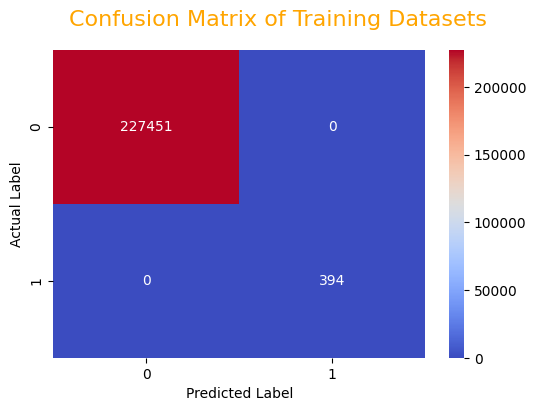

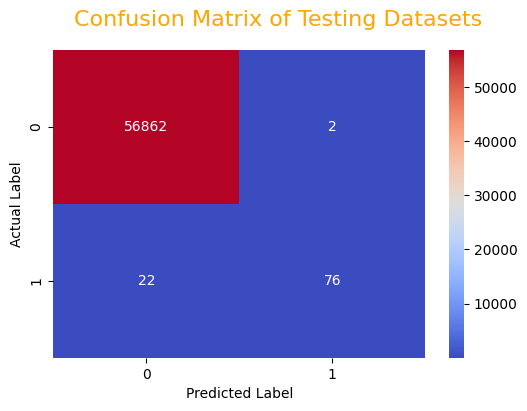

In [27]:
# RandomForestClassifier on normal datasets
RF_model(X, y)

Spliting Datasets....
Successfully splitted!!!
Model Fitting.....
Successfully model fitted!!!
------------Training Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



Accuracy Score:

100.000000%

------------Test Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Accuracy Score:

99.957867%



(RandomForestClassifier(),
                V1        V2         V3        V4         V5        V6  \
 43428  -16.526507  8.584972 -18.649853  9.505594 -13.793819 -2.832404   
 49906    0.339812 -2.743745  -0.134070 -1.385729  -1.451413  1.015887   
 29474    1.399590 -0.590701   0.168619 -1.029950  -0.539806  0.040444   
 276481  -0.432071  1.647895  -1.669361 -0.349504   0.785785 -0.630647   
 278846   2.014160 -0.137394  -1.015839  0.327269  -0.182179 -0.956571   
 ...           ...       ...        ...       ...        ...       ...   
 75723   -1.994348  1.503076  -0.365560  0.780223  -0.957956  0.038648   
 252263  -0.234567  0.733694   0.486250 -0.718186   0.782227 -0.788837   
 221246   0.040441 -0.109737  -1.266430  1.004783   2.223390 -0.670372   
 81910   -0.495048  0.991481   1.671584 -0.342474   0.470012 -0.348503   
 59490   -1.590486  0.992415  -0.512841  1.120752  -1.916756  3.142176   
 
                V7        V8        V9        V10  ...       V20       V21  \
 4342

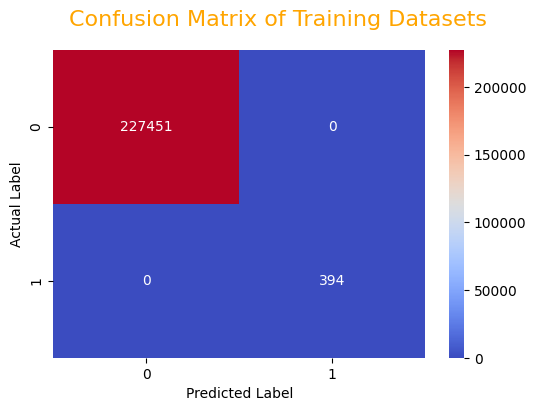

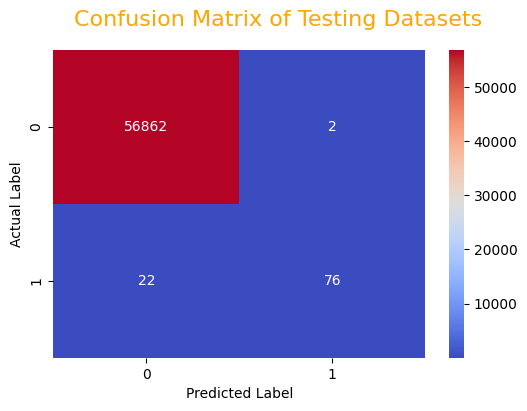

In [28]:
# RandomForestClassifier on StandardScaled Dataset
RF_model(X_scaled, y_scaled)

Spliting Datasets....
Successfully splitted!!!
Model Fitting.....
Successfully model fitted!!!
------------Training Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       393
           1       1.00      1.00      1.00       394

    accuracy                           1.00       787
   macro avg       1.00      1.00      1.00       787
weighted avg       1.00      1.00      1.00       787



Accuracy Score:

100.000000%

------------Test Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        99
           1       0.96      0.89      0.92        98

    accuracy                           0.92       197
   macro avg       0.93      0.92      0.92       197
weighted avg       0.93      0.92      0.92       197



Accuracy Score:

92.385787%



(RandomForestClassifier(),
                V1         V2         V3        V4        V5        V6  \
 42756  -10.645800   5.918307 -11.671043  8.807369 -7.975501 -3.586806   
 1686    -1.379848   0.536720   2.647870  1.408111  0.126442  0.986525   
 111690  -4.198735   0.194121  -3.917586  3.920748 -1.875486 -2.118933   
 128360  -0.671155   1.183971   0.793623 -0.218410  0.357282 -0.023707   
 20746    1.087002   0.065459   0.485043  1.343874 -0.283361  0.002520   
 ...           ...        ...        ...       ...       ...       ...   
 89723    1.100963   0.016821   1.069516  1.501387 -0.639284  0.088885   
 200118   1.895817  -0.111575  -1.787544  0.339969  0.243479 -0.722965   
 6641     0.857321   4.093912  -7.423894  7.380245  0.973366 -2.730762   
 33631    1.438450  -1.108186   0.765152 -1.183354 -2.056695 -1.345164   
 102441 -13.192671  12.785971  -9.906650  3.320337 -4.801176  5.760059   
 
                V7         V8        V9        V10  ...       V20        V21  \
 42

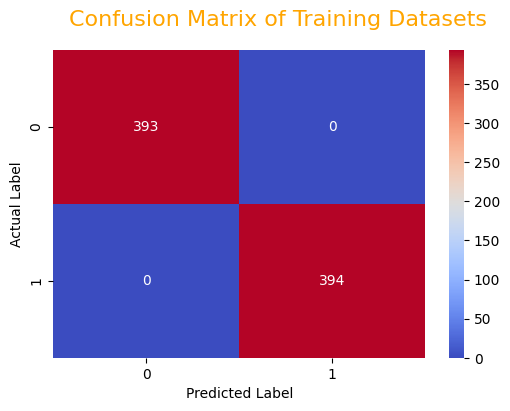

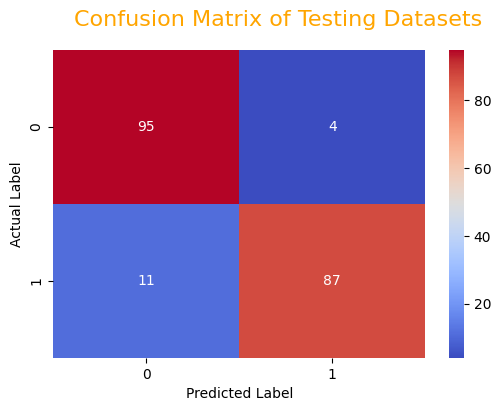

In [29]:
# RandomForestClassifier on Undersampled Dataset
RF_model(X_undersampled, y_undersampled)

Spliting Datasets....
Successfully splitted!!!
Model Fitting.....
Successfully model fitted!!!
------------Training Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227335
           1       1.00      1.00      1.00    227569

    accuracy                           1.00    454904
   macro avg       1.00      1.00      1.00    454904
weighted avg       1.00      1.00      1.00    454904



Accuracy Score:

100.000000%

------------Test Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56980
           1       1.00      1.00      1.00     56746

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



Accuracy Score:

99.996483%



(RandomForestClassifier(),
               V1        V2        V3        V4        V5        V6        V7  \
 153393  1.824858 -0.539107 -0.239213  0.540798 -0.822211 -0.495407 -0.687954   
 220313 -2.782131 -4.427934  0.239835  0.697189  4.871723 -4.262493 -2.181822   
 156990 -1.000611  3.346850 -5.534491  6.835802 -0.299803  0.095951 -2.440419   
 104328 -1.174637  1.003078  1.649672  0.526730  0.293577  1.536427 -0.257407   
 140461  1.219703 -0.443598  0.182185 -0.222885 -0.492133  0.075409 -0.568620   
 ...          ...       ...       ...       ...       ...       ...       ...   
 8972   -4.064005  3.100935 -1.188498  3.264633 -1.903562  0.320351 -0.954940   
 157585  1.934946  0.650678 -0.286957  3.987828  0.316052 -0.099449 -0.021483   
 200136 -0.138187 -0.905671  0.828887 -0.523203 -0.984487 -0.451989 -0.037213   
 142669 -1.444927  1.400376  0.728841 -1.614656 -0.062750 -0.734057  0.582677   
 6903   -2.535852  5.793644 -7.618463  6.395830 -0.065210 -3.136372 -3.104557   
 

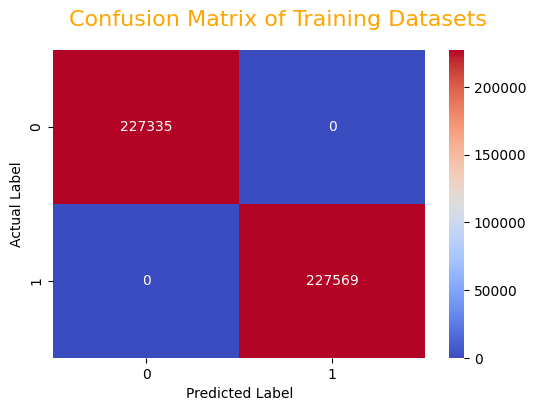

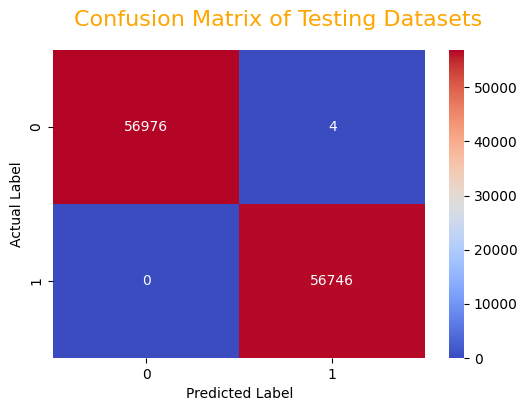

In [30]:
# RandomForestClassifier on Oversampled Dataset
RF_model(X_oversampled, y_oversampled)

Spliting Datasets....
Successfully splitted!!!
Model Fitting.....
Successfully model fitted!!!
------------Training Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227565
           1       1.00      1.00      1.00    227339

    accuracy                           1.00    454904
   macro avg       1.00      1.00      1.00    454904
weighted avg       1.00      1.00      1.00    454904



Accuracy Score:

100.000000%

------------Test Prediction--------------
Classfifcation Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



Accuracy Score:

99.990328%



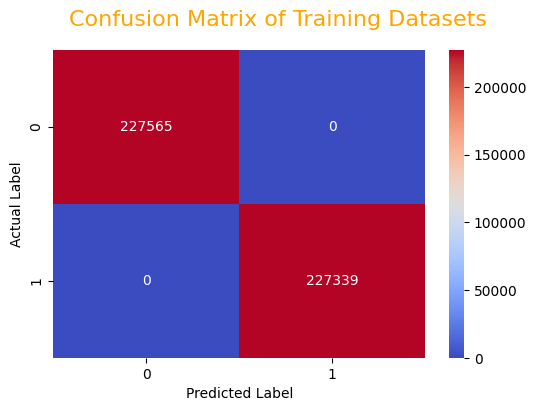

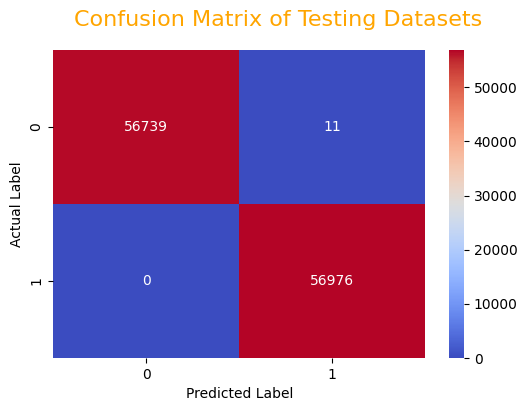

In [31]:
# RandomForestClassifier on SMOTE Dataset
rf_model, X_test, y_test = RF_model(X_smote, y_smote)

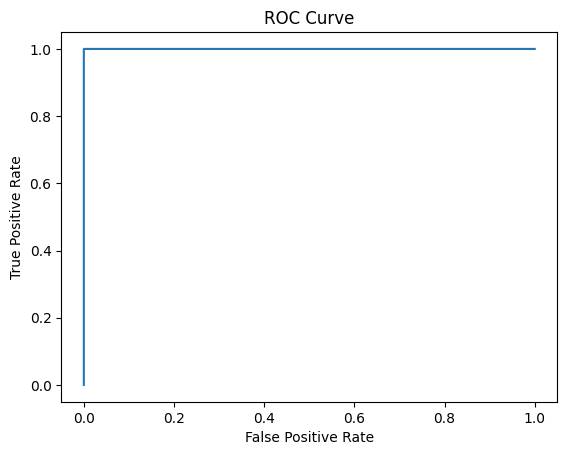

ROC-AUC Score: 0.9999992982592872


In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# Feature Importance

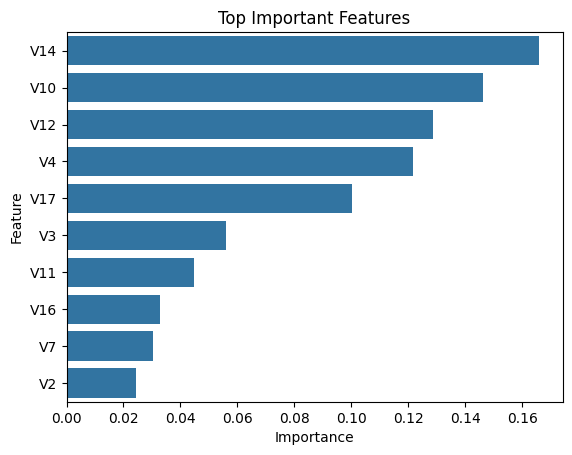

In [33]:
importance = rf_model.feature_importances_

features = X_smote.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top Important Features")
plt.show()

# Model Comparison

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.94      0.98      0.96     56750
           1       0.98      0.94      0.96     56976

    accuracy                           0.96    113726
   macro avg       0.96      0.96      0.96    113726
weighted avg       0.96      0.96      0.96    113726



Conclusions
This project implemented a Credit Card Fraud Detection System using a Random Forest Classifier on a highly imbalanced dataset.

Different resampling techniques such as undersampling, oversampling, and SMOTE were applied to address class imbalance. Among these, SMOTE provided the best balance between precision and recall.

Undersampling was found to be less effective for large datasets as it removes valuable information, whereas oversampling and SMOTE preserved important patterns.

Although the model achieved very high accuracy, it is not considered a reliable metric for imbalanced datasets. Therefore, recall, F1-score, and ROC-AUC were used for evaluation.

The ROC curve demonstrated excellent classification performance with an AUC score close to 1, indicating strong separability between fraud and normal transactions.

Feature importance analysis revealed key attributes contributing to fraud detection, improving model interpretability.

Overall, Random Forest proved to be a robust and effective model for fraud detection. Future work can include advanced models like XGBoost and real-time deployment systems.